# 电信客户生存分析 (Customer Survival Analysis)

## 第1步 导入依赖库

In [1]:
# ============================================
# 第 1 步：导入依赖库
# ============================================

import pandas as pd          # 数据处理
import numpy as np           # 数值计算
import matplotlib.pyplot as plt  # 绘图
from matplotlib.font_manager import FontProperties

# 中文字体配置（直接指定字体文件路径）
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'
font_prop = FontProperties(fname=font_path)

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
from lifelines import KaplanMeierFitter, CoxPHFitter, LogLogisticAFTFitter  # 生存分析模型
from lifelines.statistics import pairwise_logrank_test  # 统计检验
import os                    # 文件操作

print(" 依赖库加载完成")
print(f"   pandas: {pd.__version__}")
print(f"   numpy: {np.__version__}")

 依赖库加载完成
   pandas: 2.3.3
   numpy: 2.4.1


## 第 2 步：加载数据

### 关键操作
1. 检查本地是否有数据文件，没有则下载
2. 空格替换为下划线 - 方便后续访问

In [2]:
# ============================================
# 第 2 步：加载数据
# ============================================

# 数据文件路径
LOCAL = 'Telco-Customer-Churn.csv'

# 如果本地没有数据，从 GitHub 下载
if not os.path.exists(LOCAL):
    import urllib.request
    print("  下载数据...")
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv',
        LOCAL
    )

# 读取 CSV 文件
df = pd.read_csv(LOCAL)

# 统一列名格式：全部转小写，空格替换为下划线
# 例如：'customerID' -> 'customerid', 'TotalCharges' -> 'totalcharges'
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(f" 数据加载完成")
print(f"   数据量：{len(df)} 条 × {len(df.columns)} 列")
print(f"   列名：{df.columns.tolist()}")

 数据加载完成
   数据量：7043 条 × 21 列
   列名：['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [3]:
# ============================================
# 验证数据加载正确
# ============================================

# 检查关键列是否存在（避免 KeyError）
print(" 数据验证:")
print(f"   'churn' 列是否存在：{'churn' in df.columns}")
print(f"   'tenure' 列是否存在：{'tenure' in df.columns}")

# 查看 churn 列的唯一值（应该是 'Yes' 和 'No'）
print(f"   churn 列唯一值：{df['churn'].unique()}")

# 查看前 5 条数据
print("\n前 5 条数据:")
df.head()

 数据验证:
   'churn' 列是否存在：True
   'tenure' 列是否存在：True
   churn 列唯一值：['No' 'Yes']

前 5 条数据:


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 第 3 步：数据预处理

### 处理内容
1. **转换目标变量** - churn: 'Yes'→1, 'No'→0
2. **筛选样本** - 只保留月付用户 + 有互联网服务的用户
3. **删除无关列** - totalcharges 有缺失值，删除

In [4]:
# ============================================
# 第 3 步：数据预处理
# ============================================

# 创建副本，避免修改原始数据
data = df.copy()

# --- 3.1 转换目标变量 ---
# 将 churn 从字符串 ('Yes'/'No') 转换为数值 (1/0)
# 1 = 流失 (事件发生), 0 = 未流失 (删失)
data['churn'] = data['churn'].map({'Yes': 1, 'No': 0}).astype(float)
print(f" churn 转换完成：{data['churn'].value_counts().to_dict()}")

# --- 3.2 筛选样本 ---
# 只分析月付用户（合同类型='Month-to-month'）
# 原因：这类用户流失风险最高，最有分析价值
data = data[data['contract'] == 'Month-to-month']
print(f" 筛选月付用户：{len(data)} 条")

# 只保留有互联网服务的用户
# 原因：互联网服务类型是重要的风险因素
data = data[data['internetservice'] != 'No']
print(f" 筛选有互联网服务：{len(data)} 条")

# --- 3.3 删除无关列 ---
# totalcharges 有缺失值，且与 tenure 高度相关，删除
data = data.drop(['totalcharges'], axis=1)

# 最终数据概览
print(f"\n 最终数据集:")
print(f"   样本数：{len(data)}")
print(f"   流失率：{data['churn'].mean():.1%}")
print(f"   特征数：{len(data.columns)}")

 churn 转换完成：{0.0: 5174, 1.0: 1869}
 筛选月付用户：3875 条
 筛选有互联网服务：3351 条

 最终数据集:
   样本数：3351
   流失率：46.4%
   特征数：20


## 第 4 步：Kaplan-Meier 生存曲线

### 什么是 KM 曲线？
- 描述随时间推移，客户"存活"（未流失）的概率
- 中位生存时间：50% 客户流失时的时间点

### 关键变量
- **T (tenure)**: 生存时间（客户在网月数）
- **C (churn)**: 事件指示（1=流失，0=删失）


 图表已保存：survival_curve.png


/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/1162992985.py:22: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAP

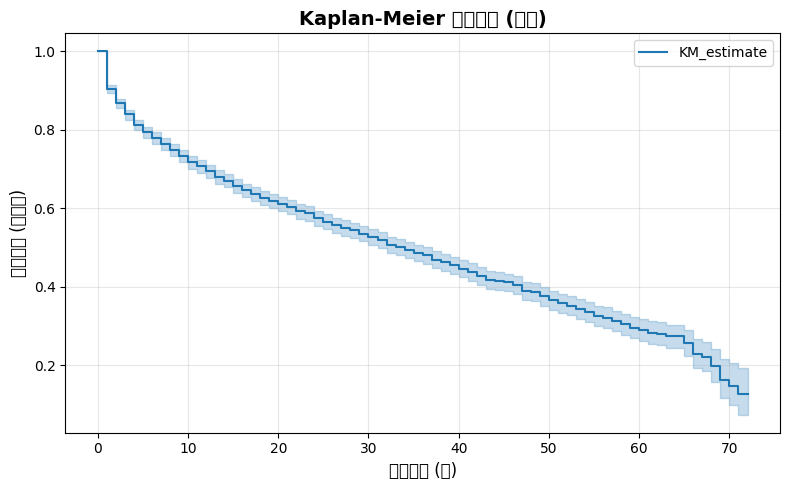

In [5]:
# ============================================
# 第 4 步：Kaplan-Meier 生存曲线
# ============================================

# 定义生存时间和事件指示
T = data['tenure']  # 生存时间：客户在网月数
C = data['churn']   # 事件指示：1=流失，0=未流失（删失）

# 创建 Kaplan-Meier 拟合器
kmf = KaplanMeierFitter()

# 拟合模型
kmf.fit(T, event_observed=C)

# 绘制生存曲线
fig, ax = plt.subplots(figsize=(8, 5))
kmf.plot_survival_function(ax=ax)
ax.set_title('Kaplan-Meier 生存曲线 (整体)', fontsize=14, fontweight='bold')
ax.set_xlabel('在网时间 (月)', fontsize=12)
ax.set_ylabel('存活概率 (未流失)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('survival_curve.png', dpi=150, bbox_inches='tight')
print(f"\n 图表已保存：survival_curve.png")

## 第 5 步：Log-rank 检验

### 目的
检验不同组别之间的生存曲线是否有显著差异

### 判断标准
- **p < 0.05**: 组间差异显著（*标注）
- **p >= 0.05**: 组间差异不显著

In [6]:
# ============================================
# 第 5 步：Log-rank 检验
# ============================================

# 定义检验函数
def logrank_test(col):
    """
    对指定列进行 Log-rank 检验
    
    参数:
        col: 要检验的特征列名
    
    返回:
        p 值
    """
    r = pairwise_logrank_test(
        event_durations=T,      # 生存时间
        event_observed=C,       # 事件指示
        groups=data[col]        # 分组变量
    )
    return float(r.p_value[0])

# 检验关键特征
print(" Log-rank 检验结果:")
print("   (p < 0.05 表示组间差异显著 *)\n")

for col in ['onlinesecurity', 'gender', 'internetservice']:
    p = logrank_test(col)
    sig = " *" if p < 0.05 else ""
    print(f"   {col}: p = {p:.4f}{sig}")


 Log-rank 检验结果:
   (p < 0.05 表示组间差异显著 *)

   onlinesecurity: p = 0.0000 *
   gender: p = 0.1533
   internetservice: p = 0.0000 *


## 第 6 步：Cox 比例风险模型

### 模型作用
- 量化各因素对流失风险的影响
- 输出风险比 (Hazard Ratio)
  - **HR > 1**: 增加流失风险
  - **HR < 1**: 降低流失风险（保护因素）

### 模型评估
- **Concordance Index**: 预测准确性（0.5=随机，1.0=完美）

In [7]:
# ============================================
# 第 6 步：Cox 比例风险模型
# ============================================

# --- 6.1 选择特征 ---
# 选择可能影响流失风险的特征
vars = ['dependents', 'internetservice', 'onlinebackup', 'techsupport', 'paperlessbilling']

# --- 6.2 独热编码 ---
# 将分类变量转换为数值（哑变量）
enc = pd.get_dummies(data, columns=vars, prefix=vars)
print(f" 独热编码完成：{len(enc.columns)} 个特征")

# --- 6.3 选择建模列 ---
# 选择关键特征进行建模
cols = ['churn', 'tenure', 'dependents_Yes', 'internetservice_DSL', 
        'onlinebackup_Yes', 'techsupport_Yes']
cox_df = enc[cols].copy()
cox_df['churn'] = cox_df['churn'].astype(float)

# --- 6.4 拟合 Cox 模型 ---
cph = CoxPHFitter(alpha=0.05)  # alpha=0.05 表示 95% 置信区间
cph.fit(cox_df, duration_col='tenure', event_col='churn')

# --- 6.5 输出结果 ---
print(f"\n Cox 比例风险模型:")
print(f"   Concordance Index: {cph.concordance_index_:.3f}")

# 打印详细结果
cph.print_summary()

 独热编码完成：25 个特征

 Cox 比例风险模型:
   Concordance Index: 0.641


<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 3351
number of events observed = 1556
   partial log-likelihood = -11315.95
         time fit was run = 2026-04-04 08:15:06 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
dependents_Yes      -0.33      0.72      0.07           -0.47           -0.19                0.63                0.83
internetservice_DSL -0.22      0.80      0.06           -0.33           -0.10                0.72                0.90
onlinebackup_Yes    -0.78      0.46      0.06           -0.89           -0.66                0.41                0.52
techsupport_Yes     -0.64      0.53      0.08           -0.79           -0.49                0.46                0.61

                     cmp to      z      p  -log2(p)
covariate                                          
dependents_Yes         0.00  -4.64 <0.005     18.12
internetservice_DSL    0.00  -3.68 <0.005     12.07
onlinebackup_Yes       0.00 -13.13 <0.005    128.37
techsupport_Yes        0.00  -8.48 <0.005     55.36
---
Concordance = 0.64
Partial AIC = 22639.90
log-likelihood ratio test = 337.77 on 4 df
-log2(p) of ll-ratio test = 236.24

## 第 7 步：AFT 模型 (加速失效时间模型)

### 与 Cox 模型的区别
- Cox: 假设风险比恒定（比例风险）
- AFT: 假设生存时间加速/减速

### 模型选择
- **AIC 越小越好** - 用于比较不同模型的拟合优度

In [8]:
# ============================================
# 第 7 步：AFT 模型 (Log-Logistic)
# ============================================

# --- 7.1 选择更多特征 ---
v2 = ['partner', 'multiplelines', 'internetservice', 'onlinesecurity', 
      'onlinebackup', 'deviceprotection', 'techsupport', 'paymentmethod']

# --- 7.2 独热编码 ---
enc2 = pd.get_dummies(data, columns=v2, prefix=v2)
print(f" 独热编码完成：{len(enc2.columns)} 个特征")

# --- 7.3 选择建模列 ---
cols2 = ['churn', 'tenure', 'partner_Yes', 'multiplelines_Yes', 
         'internetservice_DSL', 'onlinesecurity_Yes', 'onlinebackup_Yes', 
         'deviceprotection_Yes', 'techsupport_Yes',
         'paymentmethod_Bank transfer (automatic)', 
         'paymentmethod_Credit card (automatic)']
aft_df = enc2[cols2].copy()
aft_df['churn'] = aft_df['churn'].astype(float)

# --- 7.4 拟合 AFT 模型 ---
aft = LogLogisticAFTFitter()
aft.fit(aft_df, duration_col='tenure', event_col='churn')

# --- 7.5 输出结果 ---
print(f"\n Log-Logistic AFT 模型:")
print(f"   AIC: {aft.AIC_:.1f}")

 独热编码完成：31 个特征

 Log-Logistic AFT 模型:
   AIC: 13698.7


## 第 8 步：客户生命周期价值 (CLV) 计算

### CLV 公式
```
CLV = Σ [生存概率 × 月利润 / (1+折现率)^月数]
```

### 参数说明
- **月利润**: 30 元/月（假设）
- **折现率**: 10%/年（IRR）
- **预测期**: 36 个月

### 风险分层
- **低风险**: 有家属、DSL 网络、在线备份、技术支持
- **高风险**: 无上述保护因素

In [9]:
# ============================================
# 第 8 步：客户生命周期价值 (CLV) 计算
# ============================================

def calculate_clv(model, features, profit=30, irr=0.10, months=36):
    """
    计算客户生命周期价值
    
    参数:
        model: 训练好的 Cox 模型
        features: 客户特征 DataFrame
        profit: 月利润 (元)
        irr: 年折现率
        months: 预测月数
    
    返回:
        包含每月 CLV 的 DataFrame
    """
    # 月折现率
    r = irr / 12
    
    # 预测生存函数
    s = model.predict_survival_function(features)
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]  # 取第一列
    s = s.iloc[:months]  # 只取前 months 个月
    
    # 构建结果 DataFrame
    df = pd.DataFrame({
        'month': list(range(1, months+1)),
        'survival': s.values.round(2)  # 生存概率
    })
    
    # 计算期望利润
    df['expected'] = (df['survival'] * profit).round(2)
    
    # 计算净现值 (NPV)
    df['npv'] = (df['expected'] / (1+r)**df['month']).round(2)
    
    # 累计 NPV
    df['cumulative'] = df['npv'].cumsum().round(2)
    
    return df.set_index('month')


# --- 8.1 定义客户画像 ---

# 低风险客户特征（保护因素齐全）
low_risk = pd.DataFrame([{
    'dependents_Yes': 1,      # 有家属
    'internetservice_DSL': 1, # DSL 网络
    'onlinebackup_Yes': 1,    # 在线备份
    'techsupport_Yes': 1      # 技术支持
}])

# 高风险客户特征（无保护因素）
high_risk = pd.DataFrame([{
    'dependents_Yes': 0,      # 无家属
    'internetservice_DSL': 0, # 非 DSL（可能是 Fiber）
    'onlinebackup_Yes': 0,    # 无在线备份
    'techsupport_Yes': 0      # 无技术支持
}])


# --- 8.2 计算 CLV ---
low_clv = calculate_clv(cph, low_risk)
high_clv = calculate_clv(cph, high_risk)


# --- 8.3 输出结果 ---
print(f" 客户生命周期价值 (36 个月):")
print(f"\n   低风险客户:")
print(f"      特征：有家属 + DSL + 在线备份 + 技术支持")
print(f"      36 月 CLV: {low_clv.loc[36, 'cumulative']:.1f} 元")
print(f"\n   高风险客户:")
print(f"      特征：无家属 + Fiber + 无附加服务")
print(f"      36 月 CLV: {high_clv.loc[36, 'cumulative']:.1f} 元")
print(f"\n    差距：{low_clv.loc[36, 'cumulative'] - high_clv.loc[36, 'cumulative']:.1f} 元")

 客户生命周期价值 (36 个月):

   低风险客户:
      特征：有家属 + DSL + 在线备份 + 技术支持
      36 月 CLV: 843.8 元

   高风险客户:
      特征：无家属 + Fiber + 无附加服务
      36 月 CLV: 485.3 元

    差距：358.5 元


## 第 9 步：保存结果

### 输出文件
1. **survival_analysis.png** - 生存曲线 + CLV 对比图
2. **results.csv** - 关键指标汇总

/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98834/2151722371.py:26: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAP

✅ 图表已保存：survival_analysis.png
✅ 结果已保存：results.csv

 生存分析完成!

输出文件:
   survival_analysis.png - 综合图表
   survival_curve.png - 生存曲线
   results.csv - 关键指标
   Telco-Customer-Churn.csv - 原始数据


/opt/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

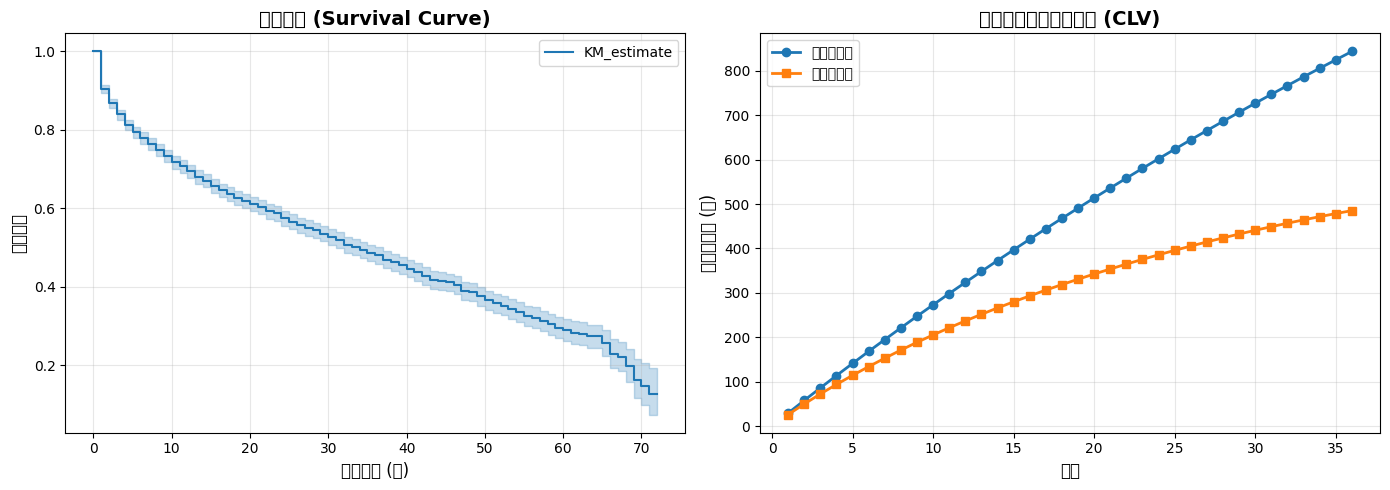

In [10]:
# ============================================
# 第 9 步：保存结果
# ============================================

# --- 9.1 绘制综合图表 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：生存曲线
kmf.plot_survival_function(ax=axes[0])
axes[0].set_title('生存曲线 (Survival Curve)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('在网时间 (月)', fontsize=12)
axes[0].set_ylabel('存活概率', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 右图：CLV 对比
axes[1].plot(low_clv.index, low_clv['cumulative'], 
             label='低风险客户', marker='o', linewidth=2, markersize=6)
axes[1].plot(high_clv.index, high_clv['cumulative'], 
             label='高风险客户', marker='s', linewidth=2, markersize=6)
axes[1].set_title('客户生命周期价值对比 (CLV)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('月数', fontsize=12)
axes[1].set_ylabel('累计净现值 (元)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
print(f"✅ 图表已保存：survival_analysis.png")


# --- 9.2 保存结果 CSV ---
results = pd.DataFrame({
    '指标': ['中位生存时间', 'Cox 一致性指数', 'AFT AIC', 
               '低风险 CLV (36 月)', '高风险 CLV (36 月)'],
    '数值': [round(kmf.median_survival_time_, 1), 
             round(cph.concordance_index_, 3), 
             round(aft.AIC_, 1),
             round(low_clv.loc[36, 'cumulative'], 1), 
             round(high_clv.loc[36, 'cumulative'], 1)]
})
results.to_csv('results.csv', index=False, encoding='utf-8-sig')
print(f"✅ 结果已保存：results.csv")


# --- 9.3 完成提示 ---
print("\n" + "="*50)
print(" 生存分析完成!")
print("="*50)
print("\n输出文件:")
print("   survival_analysis.png - 综合图表")
print("   survival_curve.png - 生存曲线")
print("   results.csv - 关键指标")
print("   Telco-Customer-Churn.csv - 原始数据")